In [18]:
# --- 0. Setup and Imports ---
import geopandas as gpd
import pandas as pd
import numpy as np
import os
# import sys # Needed to add src directory to path

# --- Define Base Directory ---
BASE_DIR = os.path.abspath('../..') # Gets the current directory of the notebook

In [19]:
# --- Define Subdirectories ---
DATA_DIR = os.path.join(BASE_DIR, "data")
RESULTS_DIR = os.path.join(BASE_DIR, "Results")

In [20]:
# Import your custom GIS functions
import gis_utils as gu

In [21]:
# # --- Define Input File Paths ---
# BOUNDARIES_PATH = os.path.join(DATA_DIR, "swissBOUNDARIES3D_1_5_LV95_LN02.gpkg")
# SWISSTLM_PATH = os.path.join(DATA_DIR, "SWISSTLM3D_2025.gpkg") # Verify filename
# CORINE_PATH = os.path.join(DATA_DIR, "U2018_CLC2018_V2020_20u1.gpkg") # Verify filename
# CORINE_LEGEND_PATH = os.path.join(DATA_DIR, "Info", "Legend", "Vector", "CLC_legend.csv") # Verify path
# COST_CSV_PATH = os.path.join(DATA_DIR, "resistance_costs.csv")

In [22]:
BOUNDARIES_PATH = os.path.join("C:\\ZHAW\\5.Semester\\PA2\\data", "swissBOUNDARIES3D_1_5_LV95_LN02.gpkg")
SWISSTLM_PATH = os.path.join("C:\\ZHAW\\5.Semester\\PA2\\data", "SWISSTLM3D_2025.gpkg")
CORINE_PATH = os.path.join("C:\\ZHAW\\5.Semester\\PA2\\data\\Results", "U2018_CLC2018_V2020_20u1.gpkg")
CORINE_LEGEND_PATH = os.path.join("C:\\ZHAW\\5.Semester\\PA2\\data\\Results\\Info\\Legend\\Vector", "CLC_legend.csv")
COST_CSV_PATH = os.path.join("C:\\ZHAW\\5.Semester\\PA2\\PA2-Modelling_Wildlife_Corridors\\data", "resistance_costs.csv")

In [23]:
# --- Define Output File Paths ---
# Intermediate Type Rasters
LANDCOVER_SWISSTLM_RASTER = os.path.join(RESULTS_DIR, "temp_swisstlm_lc_resist.tif")
LANDCOVER_CORINE_RASTER = os.path.join(RESULTS_DIR, "temp_corine_lc_resist.tif")
HARMONIZED_TYPE_RASTER = os.path.join(RESULTS_DIR, "harmonized_landcover_type.tif")
# Barrier Rasters
WATER_BARRIER_RASTER = os.path.join(RESULTS_DIR, "temp_water_barrier.tif")
ROAD_BARRIER_RASTER = os.path.join(RESULTS_DIR, "temp_road_barrier.tif")
# Final Output
FINAL_RASTER = os.path.join(RESULTS_DIR, "final_resistance_surface.tif")

In [24]:
# --- Define Workflow Settings ---
TARGET_CANTON = "Schaffhausen"
BUFFER_M = 10000
TARGET_RESOLUTION_M = 10.0
# MIN_VALID_COST = 5.0 # Value to replace NoData during MAX combination
MAX_BARRIER_COST = 1000 # For plotting normalization
# DEFAULT_RESISTANCE_COST = 255 # High cost for unexpected landcover types

In [25]:
# --- Define Canton and bounding box ---
sh, sh_bbox = gu.filter_canton(TARGET_CANTON, BOUNDARIES_PATH, buffer_m=BUFFER_M)
target_crs = sh.crs
gu.plot_vector_layer(sh, f"{TARGET_CANTON} Canton with {BUFFER_M}m Buffer")

AttributeError: module 'gis_utils' has no attribute 'filter_canton'

In [ ]:
# --- Load and Prepare Vector Layers ---
# Load Landcover Layers
landcover_sh_raw = gu.load_and_clip_vector(SWISSTLM_PATH, "tlm_bb_bodenbedeckung", sh, sh_bbox)
# Filter water out of landcover layer
landcover_sh = landcover_sh_raw[~landcover_sh_raw['objektart'].isin(['Fliessgewaesser', 'Stehende Gewaesser'])].copy()

# Load Corine + Legend
landcover_clc_raw = gpd.read_file(CORINE_PATH, layer="U2018_CLC2018_V2020_20u1", engine="pyogrio")
clc_legend = pd.read_csv(CORINE_LEGEND_PATH, sep=';')
landcover_clc_raw['Code_18'] = landcover_clc_raw['Code_18'].astype(int)
landcover_clc_with_labels = landcover_clc_raw.merge(clc_legend[['CLC_CODE', 'LABEL3']], left_on='Code_18', right_on='CLC_CODE', how='left')
if landcover_clc_with_labels.crs != target_crs: landcover_clc_with_labels = landcover_clc_with_labels.to_crs(target_crs)
landcover_sh_clc_unfiltered = gpd.clip(landcover_clc_with_labels, sh) # Clip before filtering water
# Filter water out of Corine
landcover_sh_clc_clipped = landcover_sh_clc_unfiltered[~landcover_sh_clc_unfiltered['LABEL3'].isin(['Water bodies', 'Water courses'])].copy()

# Load Water & Combine
f_water_sh = gu.load_and_clip_vector(SWISSTLM_PATH, "tlm_gewaesser_fliessgewaesser", sh, sh_bbox)
s_water_sh = gu.load_and_clip_vector(SWISSTLM_PATH, "tlm_gewaesser_stehendes_gewaesser", sh, sh_bbox)
water_sh_combined = gpd.GeoDataFrame(pd.concat([f_water_sh, s_water_sh], ignore_index=True), crs=target_crs)

# Load Roads
roads_sh = gu.load_and_clip_vector(SWISSTLM_PATH, "tlm_strassen_strasse", sh, sh_bbox)



--- 2. Load and Prepare Vector Layers ---
Loading and clipping vector: tlm_bb_bodenbedeckung from SWISSTLM3D_2025.gpkg
Clipping tlm_bb_bodenbedeckung to AOI geometry...
Loaded and clipped 9806 features from tlm_bb_bodenbedeckung.
Loading and clipping vector: tlm_gewaesser_fliessgewaesser from SWISSTLM3D_2025.gpkg
Clipping tlm_gewaesser_fliessgewaesser to AOI geometry...
Loaded and clipped 7631 features from tlm_gewaesser_fliessgewaesser.
Loading and clipping vector: tlm_gewaesser_stehendes_gewaesser from SWISSTLM3D_2025.gpkg
Clipping tlm_gewaesser_stehendes_gewaesser to AOI geometry...
Loaded and clipped 1672 features from tlm_gewaesser_stehendes_gewaesser.
Loading and clipping vector: tlm_strassen_strasse from SWISSTLM3D_2025.gpkg
Clipping tlm_strassen_strasse to AOI geometry...
Loaded and clipped 85271 features from tlm_strassen_strasse.


In [9]:
print(np.unique(landcover_sh_clc_clipped['LABEL3']))

NameError: name 'landcover_sh_clc_clipped' is not defined

In [ ]:
# --- Define Landcover Harmonization Maps ---
UNIFIED_NODATA_CODE = 0
swisstlm_to_unified_map = {'Wald': 'Forest', 
                           'Gebueschwald': 'Scrub/Shrubland', 
                           'Gehoelzflaeche': 'Scrub/Shrubland', 
                           'Wald offen': 'Open Forest/Edge', 
                           'Feuchtgebiet': 'Wetland', 
                           'Fels': 'Rocky/Bare', 
                           'Felsbloecke locker': 'Rocky/Bare', 
                           'Lockergestein': 'Rocky/Bare', 
                           'Lockergestein locker': 'Rocky/Bare'}
corine_to_unified_map = {'Broad-leaved forest': 'Forest', 
                         'Coniferous forest': 'Forest', 
                         'Mixed forest': 'Forest', 
                         'Land principally occupied by agriculture, with significant areas of natural vegetation': 'Agriculture Complex', 
                         'Complex cultivation patterns': 'Agriculture Complex', 
                         'Fruit trees and berry plantations': 'Orchards/Vineyards', 
                         'Pastures': 'Pasture/Grassland', 
                         'Non-irrigated arable land': 'Arable Land', 
                         'Vineyards': 'Orchards/Vineyards', 
                         'Sport and leisure facilities': 'Extraction/Leisure', 
                         'Mineral extraction sites': 'Extraction/Leisure', 
                         'Road and rail networks and associated land': 'Infrastructure', 
                         'Discontinuous urban fabric': 'Urban Fabric', 
                         'Continuous urban fabric': 'Urban Fabric', 
                         'Industrial or commercial units': 'Industrial/Commercial'}

Plotting vector layer: SwissTLM LC with Type Codes


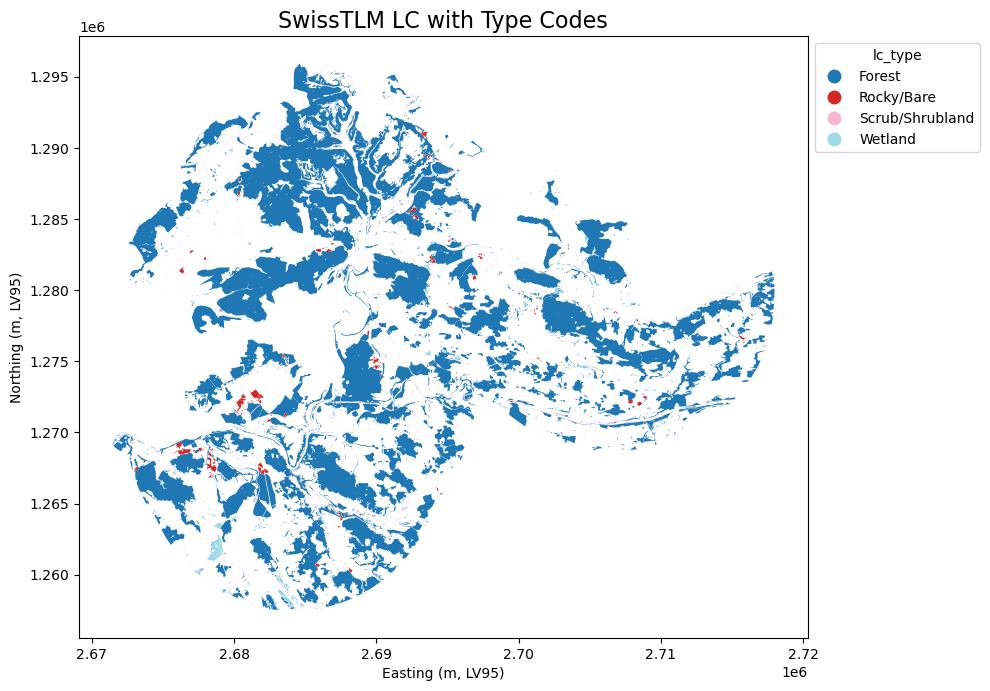

Plotting vector layer: Corine LC with Type Codes


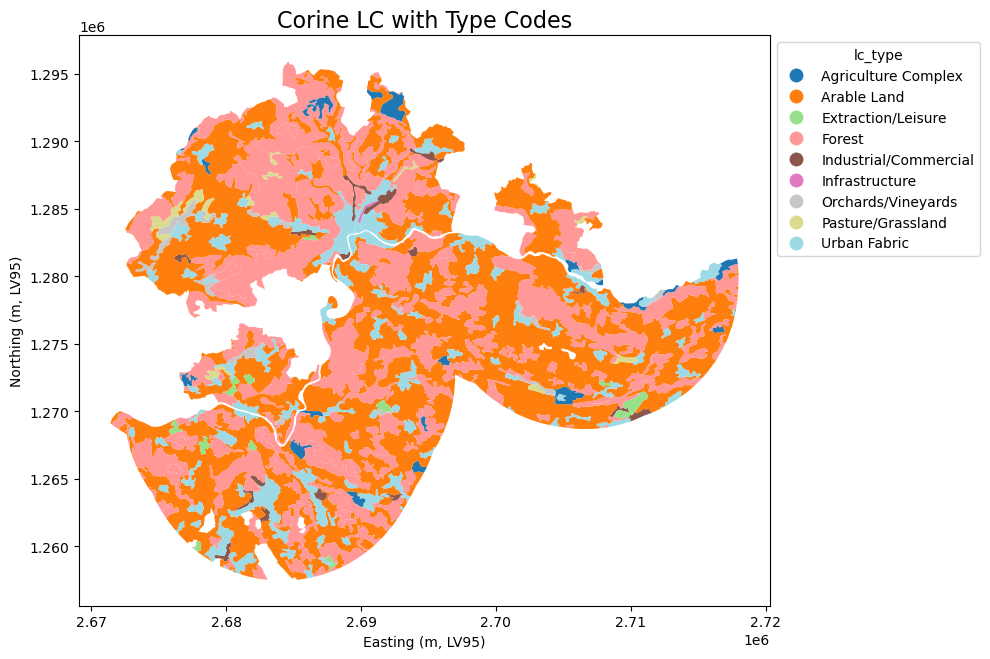

In [ ]:
# --- Apply UNIFIED TYPE CODES to Landcover Vectors ---
landcover_sh['lc_type'] = landcover_sh['objektart'].map(swisstlm_to_unified_map)
landcover_sh_clc_clipped['lc_type'] = landcover_sh_clc_clipped['LABEL3'].map(corine_to_unified_map)

# Plot vectors colored by lc_type
gu.plot_vector_layer(landcover_sh, "SwissTLM LC with Type Codes", column_to_plot='lc_type', cmap='tab20')
gu.plot_vector_layer(landcover_sh_clc_clipped, "Corine LC with Type Codes", column_to_plot='lc_type', cmap='tab20')


In [ ]:
# --- Define Master Grid ---
# Define grid for rasterization and combination of the layers based on the Canton geometry
master_meta = gu.define_master_grid_meta(sh, TARGET_RESOLUTION_M, target_crs)


--- 4. Define Master Grid ---
Defining master grid metadata...
Master grid: 4662x3849 pixels at 10.0m resolution.


In [ ]:
# --- Apply Costs and Rasterize ---
# Load resistance costs from CSV
cost_maps = gu.load_resistance_costs(COST_CSV_PATH)
landcover_sh['resistance_cost'] = landcover_sh['objektart'].map(cost_maps.get('swisstlm', {})).fillna(gu.DEFAULT_NODATA)
landcover_sh_clc_clipped['resistance_cost'] = landcover_sh_clc_clipped['LABEL3'].map(cost_maps.get('corine', {})).fillna(gu.DEFAULT_NODATA)
water_sh_combined['resistance_cost'] = water_sh_combined['objektart'].map(cost_maps.get('water', {})).fillna(gu.NODATA_VALUE)
roads_sh['resistance_cost'] = roads_sh['objektart'].map(cost_maps.get('roads', {})).fillna(gu.NODATA_VALUE)



In [ ]:
# --- Rasterize Landcover Layers by resistance cost ---
gu.rasterize_landcover_types(landcover_sh, master_meta, 'resistance_cost', LANDCOVER_SWISSTLM_RASTER)
gu.rasterize_landcover_types(landcover_sh_clc_clipped, master_meta, 'resistance_cost', LANDCOVER_CORINE_RASTER)

# Plot intermediate type rasters
gu.plot_raster_layer(LANDCOVER_SWISSTLM_RASTER, "Rasterized SwissTLM Types", cmap='RdYlGn_r', vmin=1, vmax=100)
gu.plot_raster_layer(LANDCOVER_CORINE_RASTER, "Rasterized Corine Types", cmap='RdYlGn_r', vmin=1, vmax=100)


In [ ]:
# --- Combine Landcover Rasters (Priority Fill) ---
gu.combine_rasters_priority_fill(LANDCOVER_SWISSTLM_RASTER, LANDCOVER_CORINE_RASTER, 
                                 HARMONIZED_TYPE_RASTER)

# Plot harmonized type raster
gu.plot_raster_layer(HARMONIZED_TYPE_RASTER, "Harmonized Landcover Types", cmap='RdYlGn_r', vmin=1, vmax=100)



--- 8. Apply Costs & Rasterize BARRIERS ---
Loading resistance costs from C:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors\data\resistance_costs.csv...
Loaded costs for types: ['swisstlm', 'corine', 'water', 'roads']
Rasterizing GDF to c:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors\Results\temp_water_barrier.tif...
Burning 9303 features...
Saved raster to c:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors\Results\temp_water_barrier.tif
Rasterizing GDF to c:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors\Results\temp_road_barrier.tif...
Burning 85271 features...
Saved raster to c:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors\Results\temp_road_barrier.tif
Plotting raster layer: Rasterized Water Costs from temp_water_barrier.tif


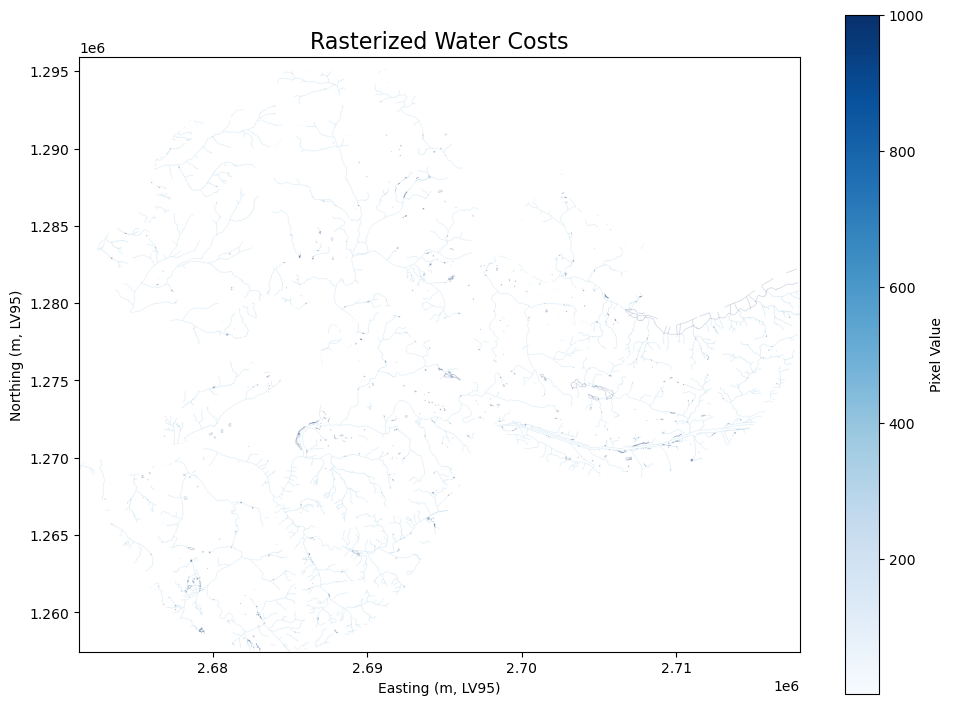

Plotting raster layer: Rasterized Road Costs from temp_road_barrier.tif


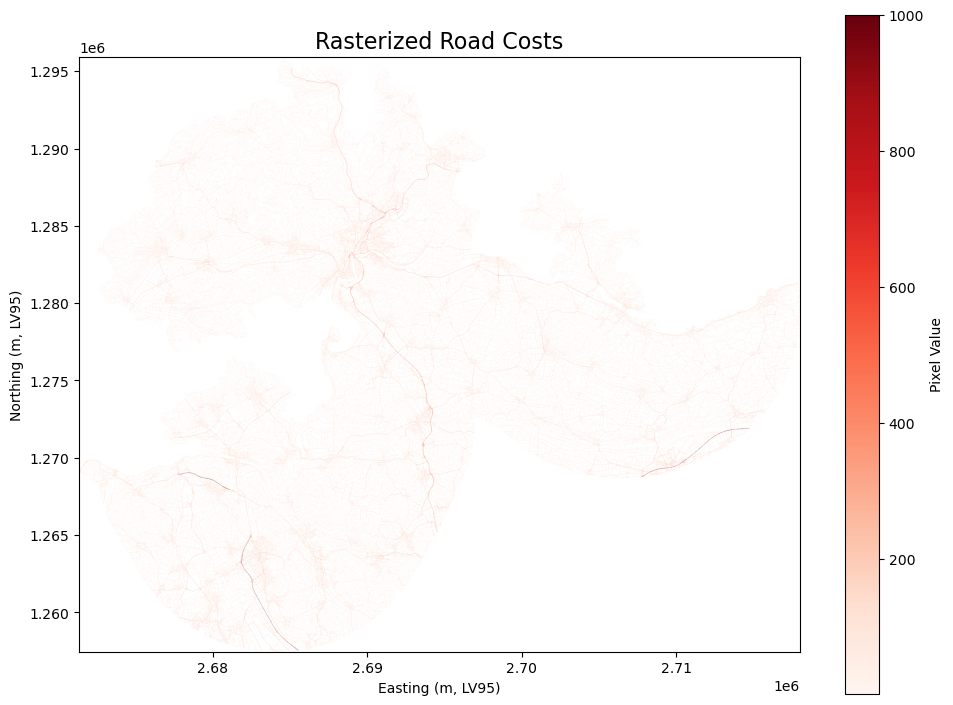

In [ ]:
# Rasterize barriers using their assigned costs
gu.rasterize_layer(water_sh_combined, master_meta, 'resistance_cost', WATER_BARRIER_RASTER)
gu.rasterize_layer(roads_sh, master_meta, 'resistance_cost', ROAD_BARRIER_RASTER)

# Plot barrier rasters
gu.plot_raster_layer(WATER_BARRIER_RASTER, "Rasterized Water Costs", cmap='RdYlGn_r', vmin=1, vmax=MAX_BARRIER_COST)
gu.plot_raster_layer(ROAD_BARRIER_RASTER, "Rasterized Road Costs", cmap='RdYlGn_r', vmin=1, vmax=MAX_BARRIER_COST)



--- 5. Rasterize Landcover Layers BY TYPE CODE ---
Rasterizing landcover types to c:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors\Results\temp_swisstlm_lc_resist.tif...
Burning 9037 features with type codes...
Saved raster to c:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors\Results\temp_swisstlm_lc_resist.tif
Rasterizing landcover types to c:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors\Results\temp_corine_lc_resist.tif...
Burning 466 features with type codes...
Saved raster to c:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors\Results\temp_corine_lc_resist.tif
Plotting raster layer: Rasterized SwissTLM Types from temp_swisstlm_lc_resist.tif


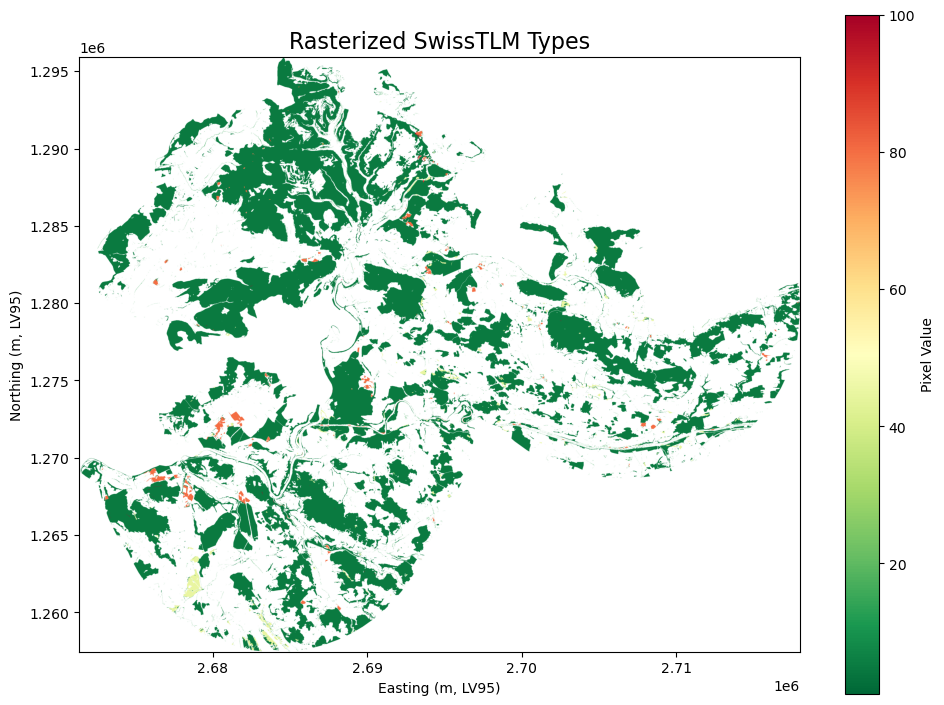

Plotting raster layer: Rasterized Corine Types from temp_corine_lc_resist.tif


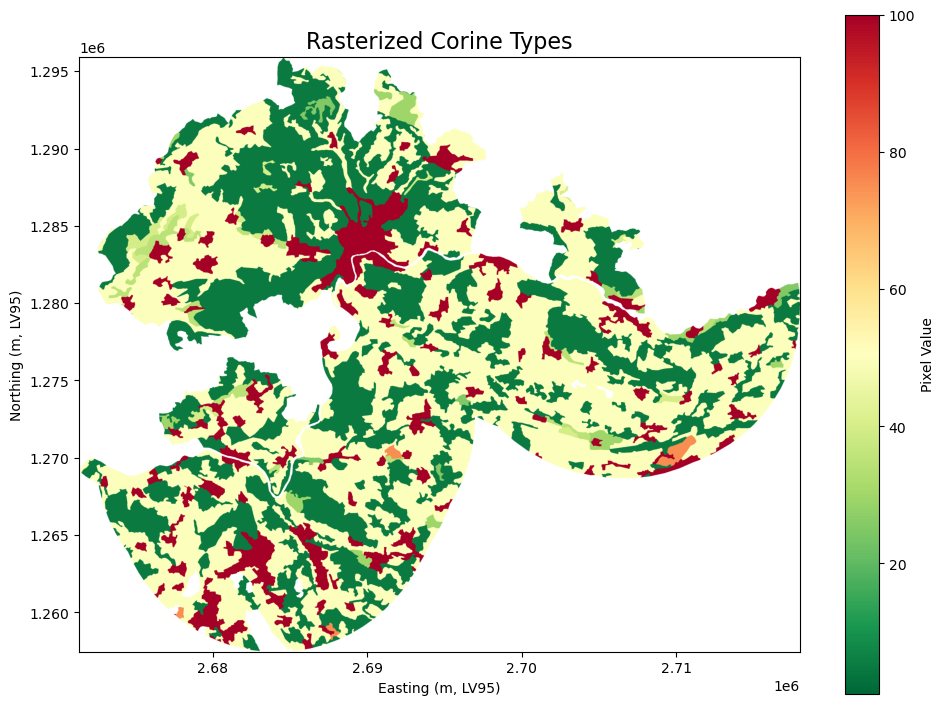


--- 6. Combine Type Rasters (Priority Fill) ---
Combining type rasters (Priority: temp_swisstlm_lc_resist.tif)...
Saved harmonized landcover type raster to c:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors\Results\harmonized_landcover_type.tif
Plotting raster layer: Harmonized Landcover Types from harmonized_landcover_type.tif


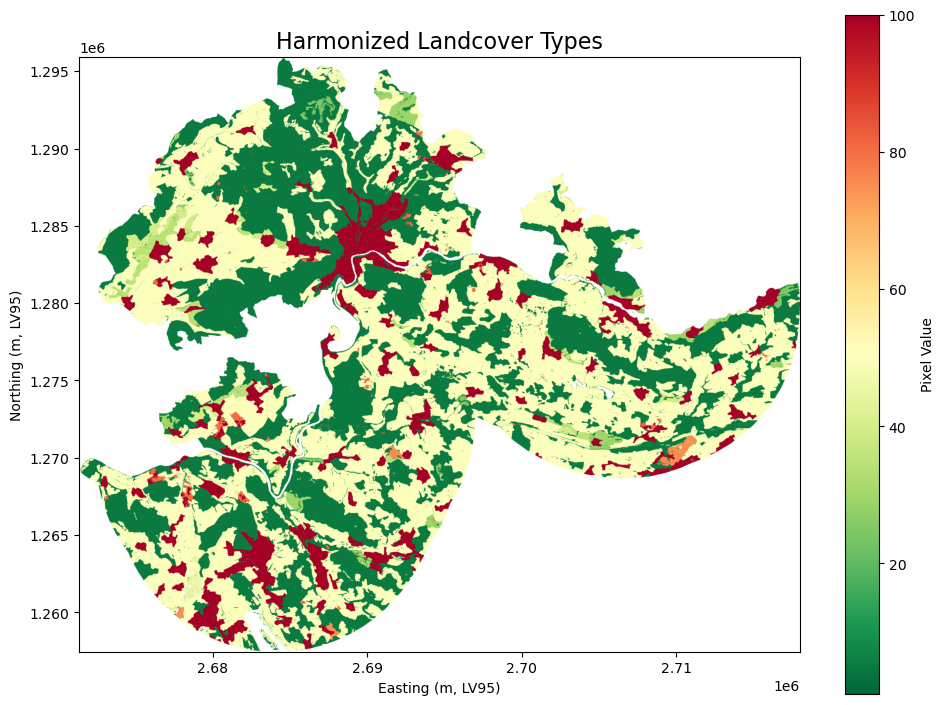

In [ ]:
print("\n--- 9. Combine FINAL Rasters (MAX Logic) ---")
input_rasters_for_final = [
    HARMONIZED_TYPE_RASTER,
    WATER_BARRIER_RASTER,
    ROAD_BARRIER_RASTER
]
valid_input_rasters = [p for p in input_rasters_for_final if os.path.exists(p)]
# if len(valid_input_rasters) < len(input_rasters_for_final): print("Warning: Some intermediate rasters missing.")

if valid_input_rasters:
    gu.combine_rasters_max_logic(valid_input_rasters, FINAL_RASTER, min_valid_cost=MIN_VALID_COST)
else: print("Error: No valid intermediate rasters found to combine.")




--- 9. Combine FINAL Rasters (MAX Logic) ---
Combining rasters using MAXIMUM logic...
Saved combined raster to c:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors\Results\final_resistance_surface.tif



--- 10. Visualize Final Result ---
Plotting cost surface: Final Resistance Surface (Harmonized LC + Barriers) from final_resistance_surface.tif


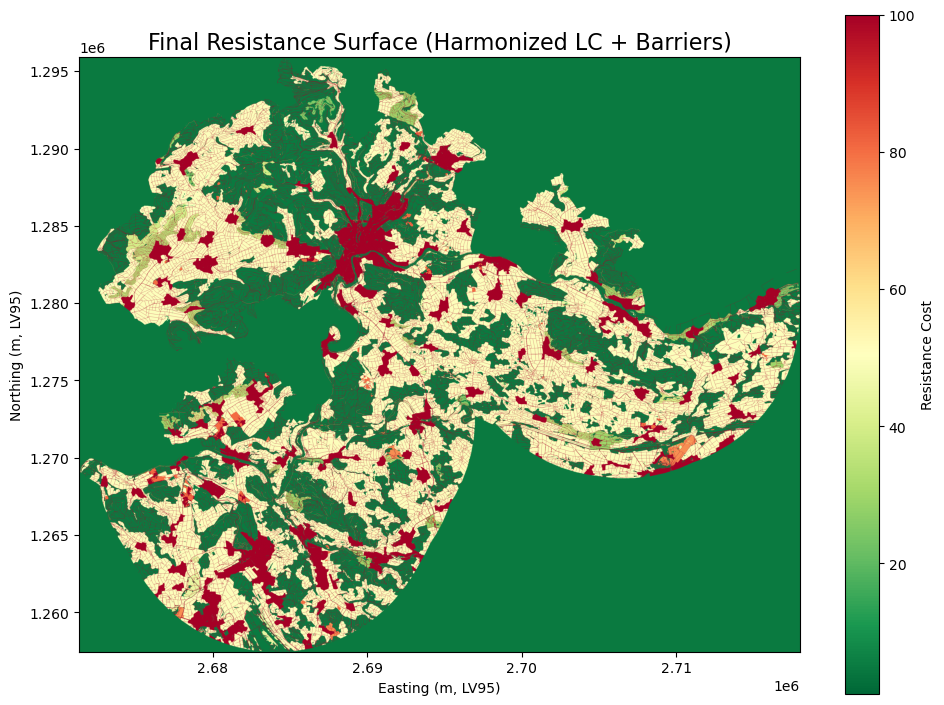


--- Harmonized Workflow Complete ---


In [ ]:
# --- Visualize Final Result ---

gu.plot_raster_layer(FINAL_RASTER, 
                     "Final Resistance Surface (Harmonized LC + Barriers)", 
                     cmap='RdYlGn_r', 
                     vmin=1, 
                     vmax=MAX_BARRIER_COST)
